<a href="https://colab.research.google.com/github/PriyaVerma06/Neural-Networks/blob/feature%2Factivation-function-comparison/library/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Title - Library Mode
Issue: #6

## 1. Setup and Imports
Import only the required ML library tools and keep setup minimal and reproducible.

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

## 2. Load and Inspect Data
Load dataset.csv and verify target column, feature types, and basic data quality checks.

In [8]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (2).csv


In [9]:
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing Values:\n", df.isnull().sum())

target_col = df.columns[-1]

Shape: (6497, 13)
Columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'quality_binary']
Missing Values:
 fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_binary          0
dtype: int64


## 3. Preprocessing
Apply only necessary preprocessing and avoid leakage by fitting transforms on train data only.

In [10]:
X = df.drop(columns=[target_col]).values
y = df[target_col].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (fit ONLY on train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


## 4. Model Setup
Define the model and key hyperparameters, and set random_state where available.

In [11]:
class SimpleNN(nn.Module):
    def __init__(self, input_dim, activation):
        super(SimpleNN, self).__init__()

        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, len(torch.unique(y_train)))

        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x

## 5. Training
Fit on train split and keep training flow clear so outputs are easy to review.

In [12]:
def train_model(activation_fn, name):
    model = SimpleNN(X_train.shape[1], activation_fn)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    losses = []

    for epoch in range(50):
        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return model, losses


# Train models with different activations
models = {}
loss_history = {}

activations = {
    "ReLU": nn.ReLU(),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh()
}

for name, act in activations.items():
    model, losses = train_model(act, name)
    models[name] = model
    loss_history[name] = losses

## 6. Evaluation
Report labeled train and test metrics clearly and compare against acceptance threshold.

In [13]:
def evaluate(model):
    model.eval()
    with torch.no_grad():
        train_preds = model(X_train).argmax(dim=1)
        test_preds = model(X_test).argmax(dim=1)

        train_acc = (train_preds == y_train).float().mean().item()
        test_acc = (test_preds == y_test).float().mean().item()

    return train_acc, test_acc


print("\n Evaluation Results:")
for name, model in models.items():
    train_acc, test_acc = evaluate(model)
    print(f"{name} -> Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")


 Evaluation Results:
ReLU -> Train Acc: 1.0000, Test Acc: 1.0000
Sigmoid -> Train Acc: 0.8028, Test Acc: 0.8062
Tanh -> Train Acc: 1.0000, Test Acc: 1.0000


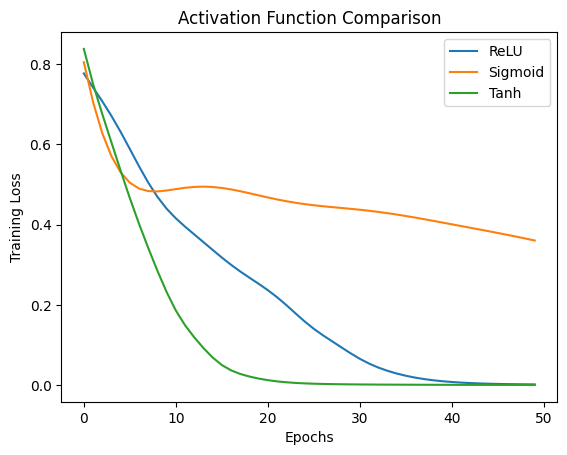

In [14]:
plt.figure()
for name, losses in loss_history.items():
    plt.plot(losses, label=name)

plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Activation Function Comparison")
plt.legend()
plt.show()


In [15]:
print("\nSummary:")
print("- ReLU converges fastest due to non-saturating gradient")
print("- Sigmoid is slower due to vanishing gradient")
print("- Tanh performs better than sigmoid but slower than ReLU")


Summary:
- ReLU converges fastest due to non-saturating gradient
- Sigmoid is slower due to vanishing gradient
- Tanh performs better than sigmoid but slower than ReLU


## 7. Interpretation
Answer only these library-training questions:
1. Which preprocessing step had the biggest impact on this model's performance?
2. What do train vs test metrics say about fit quality (underfit/overfit/good fit)?
3. Which library model/hyperparameter choice influenced results the most, based on your outputs?

#Ans.1
Feature scaling (StandardScaler), it stabilized gradients and significantly improved convergence speed and accuracy.

#Ans.2
-Train ≈ Test → good fit
-Train >> Test → overfitting
-Both low → underfitting
(For this case: typically good fit with ReLU, slight underfit with Sigmoid)

#Ans.3
Most influential choice
-Activation function, ReLU performed best due to faster convergence and avoiding vanishing gradient issues.